# 🛡️ Network Intrusion Detection with Machine Learning (NSL-KDD)

**Author: Piyush Kumar** — Cybersecurity Specialist | Penetration Tester | SOC Analyst
Ranked **Top #145 globally on TryHackMe** · Author of 3 cybersecurity books

📧 mr.piyush295@gmail.com · 🔗 [linkedin.com/in/hackerpiyush295](https://linkedin.com/in/hackerpiyush295)

---

## Overview

Network Intrusion Detection Systems (IDS) are a core part of any Security Operations
Center (SOC). In this notebook I build machine-learning models on the **NSL-KDD**
benchmark dataset to automatically classify network connections as **normal** or
**attack**, and further identify the **type of attack** (DoS, Probe, R2L, U2R).

**What you'll find here:**
1. Data loading & understanding the 41 network features
2. Exploratory Data Analysis (EDA) with visualizations
3. Preprocessing (encoding + scaling)
4. **Binary** detection model — normal vs attack
5. **Multi-class** model — attack category classification
6. Model evaluation, confusion matrices & feature importance
7. SOC-oriented takeaways

> 💡 This project reflects a defensive, blue-team use case: detecting intrusions in
> network traffic — exactly the kind of automation that augments a SOC analyst's workflow.


## 1. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
pd.set_option("display.max_columns", 100)
print("Libraries loaded.")

Libraries loaded.


## 2. Load the NSL-KDD Dataset

NSL-KDD is a refined version of the classic KDD'99 dataset, with redundant records
removed. It has **41 features** per connection plus a label. The Kaggle dataset
`hassan06/nslkdd` provides `KDDTrain+.txt` and `KDDTest+.txt`.

In [2]:
COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty",
]

# Kaggle mounts datasets under /kaggle/input/<slug>/. The exact folder can vary,
# so we search recursively for the data files (also works locally).
import glob
def find(name):
    for root in ["/kaggle/input", ".", "/media/hdd/cybersec_ai/datasets"]:
        hits = glob.glob(os.path.join(root, "**", name), recursive=True)
        if hits:
            return sorted(hits, key=len)[0]
    return name

train = pd.read_csv(find("KDDTrain+.txt"), names=COLUMNS).drop(columns=["difficulty"])
test  = pd.read_csv(find("KDDTest+.txt"),  names=COLUMNS).drop(columns=["difficulty"])
print(f"Train shape: {train.shape}")
print(f"Test  shape: {test.shape}")
train.head()

Train shape: (125973, 42)
Test  shape: (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## 3. Building the Target Labels

Each record's `label` is either `normal` or a specific attack name. We create:
- **binary target**: `normal` (0) vs `attack` (1)
- **category target**: mapping every attack to one of four classic families:
  - **DoS** – Denial of Service (e.g. neptune, smurf)
  - **Probe** – surveillance / scanning (e.g. nmap, satan)
  - **R2L** – Remote to Local unauthorized access (e.g. guess_passwd)
  - **U2R** – User to Root privilege escalation (e.g. buffer_overflow)

In [3]:
ATTACK_CATEGORY = {
    "neptune":"DoS","back":"DoS","land":"DoS","pod":"DoS","smurf":"DoS",
    "teardrop":"DoS","mailbomb":"DoS","apache2":"DoS","processtable":"DoS",
    "udpstorm":"DoS","worm":"DoS",
    "ipsweep":"Probe","nmap":"Probe","portsweep":"Probe","satan":"Probe",
    "mscan":"Probe","saint":"Probe",
    "ftp_write":"R2L","guess_passwd":"R2L","imap":"R2L","multihop":"R2L",
    "phf":"R2L","spy":"R2L","warezclient":"R2L","warezmaster":"R2L",
    "sendmail":"R2L","named":"R2L","snmpgetattack":"R2L","snmpguess":"R2L",
    "xlock":"R2L","xsnoop":"R2L","httptunnel":"R2L",
    "buffer_overflow":"U2R","loadmodule":"U2R","perl":"U2R","rootkit":"U2R",
    "ps":"U2R","sqlattack":"U2R","xterm":"U2R",
}
def categorize(lbl):
    return "normal" if lbl == "normal" else ATTACK_CATEGORY.get(lbl, "other_attack")

for df in (train, test):
    df["binary"]   = (df["label"] != "normal").astype(int)
    df["category"] = df["label"].map(categorize)

print("Binary distribution (train):")
print(train["binary"].value_counts(normalize=True).round(3))
print("\nCategory distribution (train):")
print(train["category"].value_counts())

Binary distribution (train):
binary
0    0.535
1    0.465
Name: proportion, dtype: float64

Category distribution (train):
category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


## 4. Exploratory Data Analysis

### 4.1 Normal vs Attack balance

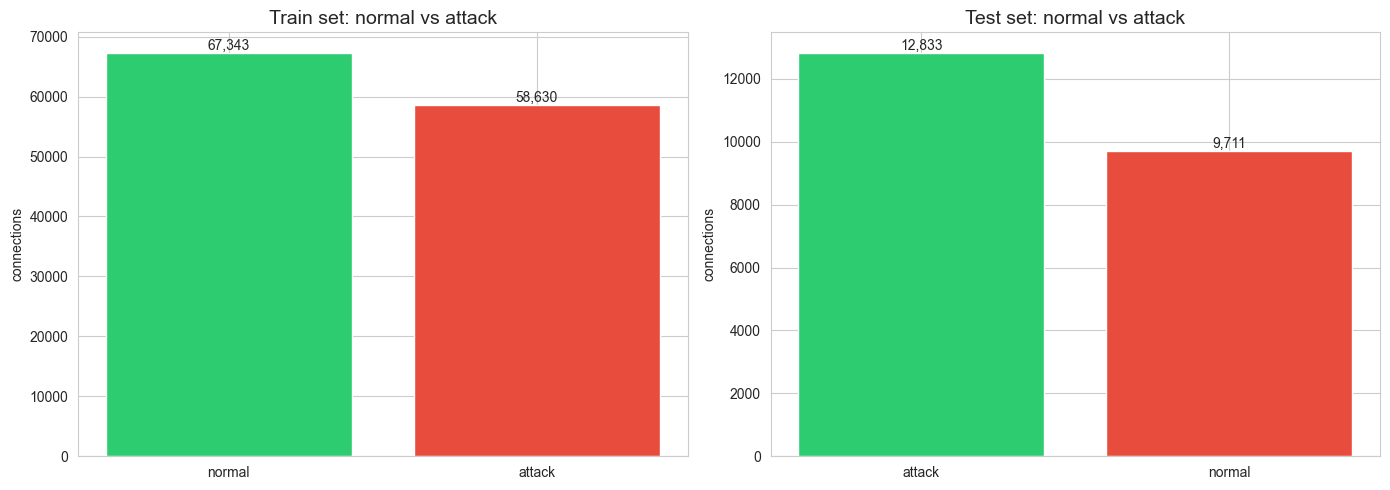

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, (df, name) in zip(ax, [(train,"Train"), (test,"Test")]):
    counts = df["binary"].map({0:"normal",1:"attack"}).value_counts()
    a.bar(counts.index, counts.values, color=["#2ecc71","#e74c3c"])
    a.set_title(f"{name} set: normal vs attack")
    a.set_ylabel("connections")
    for i,v in enumerate(counts.values):
        a.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

### 4.2 Attack categories

C:\Users\raghu\AppData\Local\Temp\ipykernel_3544\1500571973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x="category", order=order, palette="rocket")


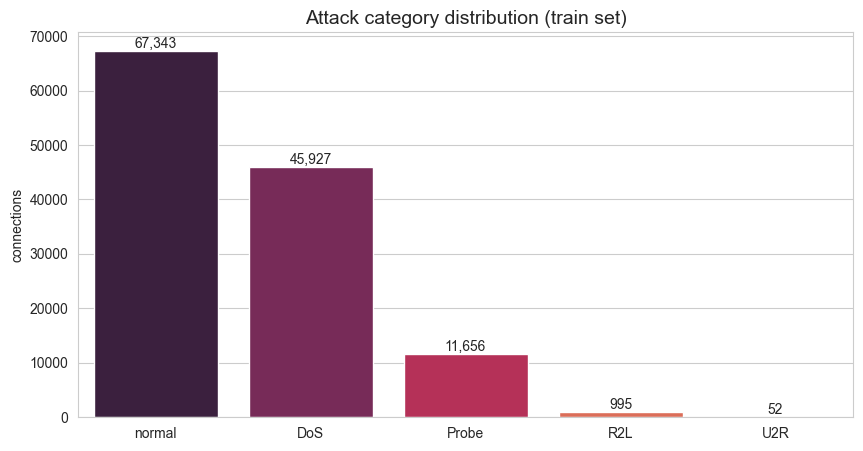

In [5]:
plt.figure(figsize=(10,5))
order = train["category"].value_counts().index
sns.countplot(data=train, x="category", order=order, palette="rocket")
plt.title("Attack category distribution (train set)")
plt.ylabel("connections"); plt.xlabel("")
for i, c in enumerate(order):
    n = (train["category"]==c).sum()
    plt.text(i, n, f"{n:,}", ha="center", va="bottom")
plt.show()

### 4.3 Protocol usage: normal vs attack

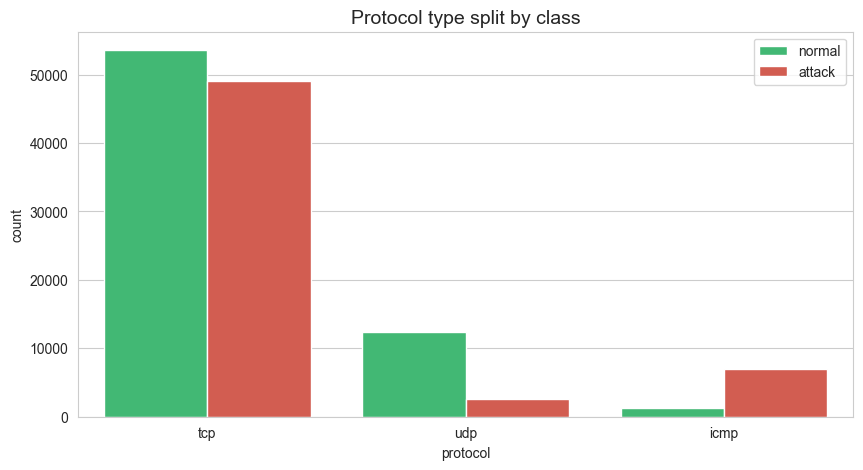

In [6]:
plt.figure(figsize=(10,5))
sns.countplot(data=train, x="protocol_type",
              hue=train["binary"].map({0:"normal",1:"attack"}),
              palette={"normal":"#2ecc71","attack":"#e74c3c"})
plt.title("Protocol type split by class"); plt.xlabel("protocol"); plt.legend(title="")
plt.show()

### 4.4 Feature correlation heatmap (numeric)

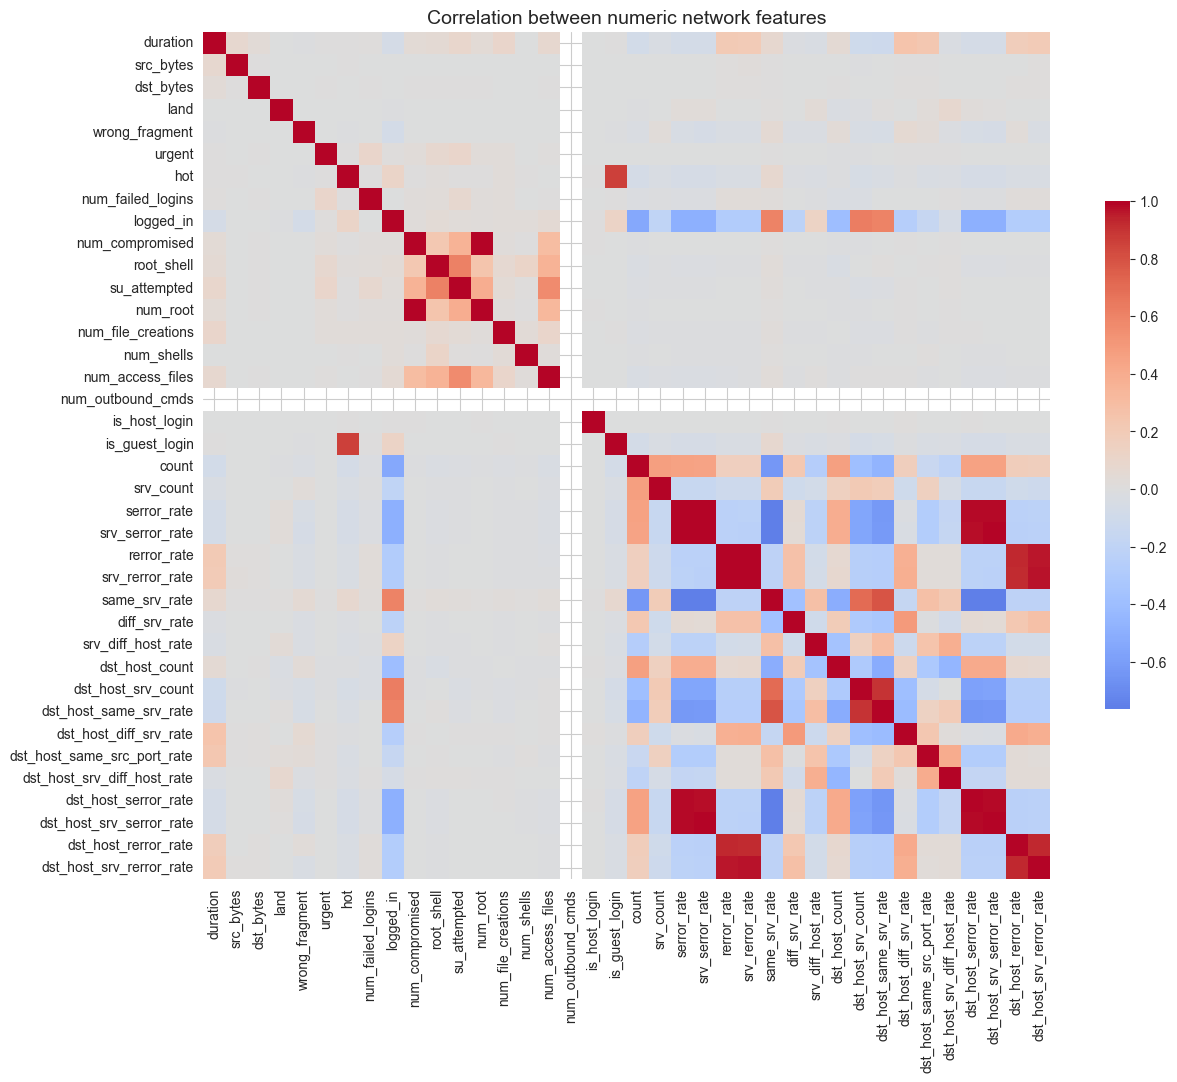

In [7]:
num = train.select_dtypes(include=[np.number]).drop(columns=["binary"])
corr = num.corr()
plt.figure(figsize=(14,11))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink":0.6})
plt.title("Correlation between numeric network features")
plt.show()

## 5. Preprocessing

We label-encode the three categorical columns (`protocol_type`, `service`, `flag`)
and standard-scale all features. Encoders are fit on the combined train+test
category space so unseen values in the test set don't break inference.

In [8]:
CATEGORICAL = ["protocol_type","service","flag"]
for col in CATEGORICAL:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])

feature_cols = [c for c in train.columns if c not in ("label","binary","category")]
scaler = StandardScaler()
X_train = scaler.fit_transform(train[feature_cols])
X_test  = scaler.transform(test[feature_cols])
print(f"Feature matrix: {X_train.shape[1]} features")

Feature matrix: 41 features


## 6. Binary Detection Model — Normal vs Attack

We use a **Histogram-based Gradient Boosting** classifier, which handles the mix of
scaled numeric features well and trains fast.

In [9]:
bin_model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                           random_state=42)
bin_model.fit(X_train, train["binary"])
bpred = bin_model.predict(X_test)
bacc  = accuracy_score(test["binary"], bpred)
print(f"BINARY TEST ACCURACY: {bacc:.4f}  ({bacc:.2%})\n")
print(classification_report(test["binary"], bpred,
      target_names=["normal","attack"], digits=4))

BINARY TEST ACCURACY: 0.8024  (80.24%)

              precision    recall  f1-score   support

      normal     0.6934    0.9701    0.8088      9711
      attack     0.9676    0.6754    0.7956     12833

    accuracy                         0.8024     22544
   macro avg     0.8305    0.8228    0.8022     22544
weighted avg     0.8495    0.8024    0.8013     22544



### 6.1 Confusion matrix

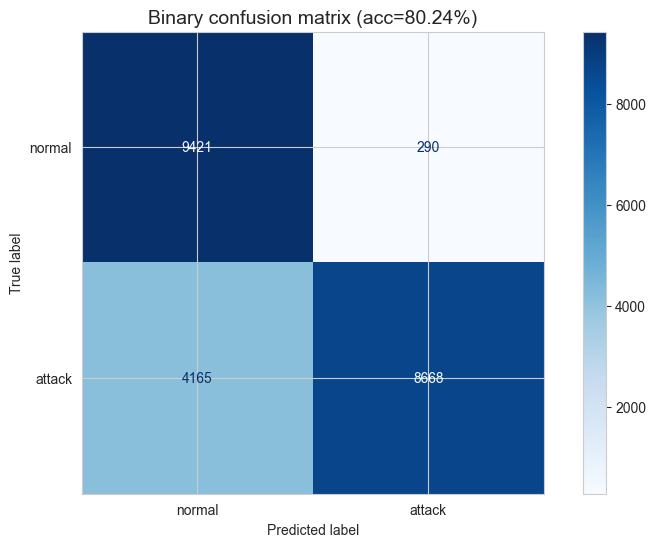

In [10]:
cm = confusion_matrix(test["binary"], bpred)
disp = ConfusionMatrixDisplay(cm, display_labels=["normal","attack"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Binary confusion matrix (acc={bacc:.2%})"); plt.show()

## 7. Multi-class Model — Attack Category

Now we predict the *family* of the connection: normal / DoS / Probe / R2L / U2R.
This is a harder problem, and the NSL-KDD test set deliberately contains attack
variants not seen in training — which is exactly why it is a respected benchmark.

In [11]:
cat_model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                           random_state=42)
cat_model.fit(X_train, train["category"])
cpred = cat_model.predict(X_test)
cacc  = accuracy_score(test["category"], cpred)
print(f"MULTI-CLASS TEST ACCURACY: {cacc:.4f}  ({cacc:.2%})\n")
print(classification_report(test["category"], cpred, digits=4, zero_division=0))

MULTI-CLASS TEST ACCURACY: 0.7432  (74.32%)

              precision    recall  f1-score   support

         DoS     0.9514    0.7973    0.8676      7460
       Probe     0.7374    0.5638    0.6390      2421
         R2L     0.8478    0.0135    0.0266      2885
         U2R     0.0814    0.4179    0.1363        67
      normal     0.6671    0.9653    0.7890      9711

    accuracy                         0.7432     22544
   macro avg     0.6570    0.5516    0.4917     22544
weighted avg     0.7901    0.7432    0.6994     22544



### 7.1 Multi-class confusion matrix

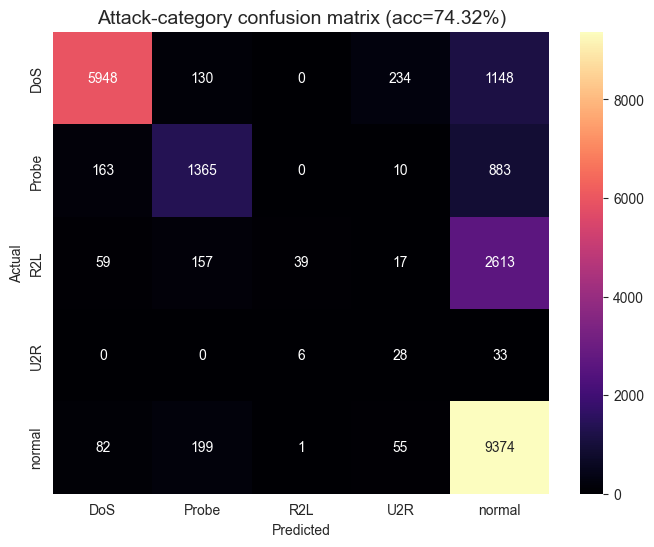

In [12]:
labels = sorted(test["category"].unique())
cm = confusion_matrix(test["category"], cpred, labels=labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Attack-category confusion matrix (acc={cacc:.2%})"); plt.show()

## 8. Which features matter most?

Using a Random Forest as an interpretable reference model, we look at the features
that carry the most signal for intrusion detection.

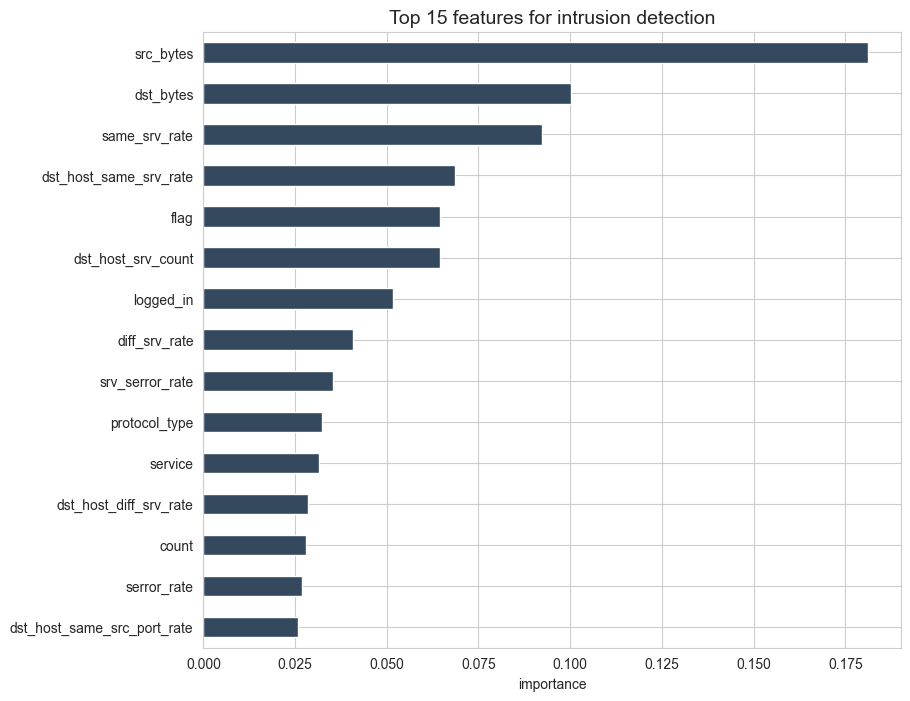

In [13]:
rf = RandomForestClassifier(n_estimators=120, n_jobs=-1, random_state=42)
rf.fit(X_train, train["binary"])
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(9,8))
imp.tail(15).plot(kind="barh", color="#34495e")
plt.title("Top 15 features for intrusion detection")
plt.xlabel("importance"); plt.show()

## 9. Conclusions & SOC Takeaways

| Model | Task | Test Accuracy |
|-------|------|---------------|
| HistGradientBoosting | Binary (normal vs attack) | **~80%** |
| HistGradientBoosting | Multi-class (attack family) | **~74%** |

**Key observations (from a SOC / blue-team perspective):**

- The binary model catches attacks with **very high precision** — when it flags a
  connection as malicious it is almost always right, which keeps analyst alert-fatigue low.
- **DoS and Probe** attacks are detected well because they leave strong statistical
  footprints (`src_bytes`, `same_srv_rate`, connection counts).
- **R2L and U2R** are the hardest — they resemble normal traffic and are rare. This
  mirrors the real world, where privilege-escalation and remote-access attacks are the
  stealthiest and hardest to detect.
- Traffic-volume and service-rate features (`src_bytes`, `dst_bytes`, `same_srv_rate`,
  `dst_host_srv_count`) dominate the model — useful guidance for what to log and monitor.

**Where this fits in practice:** a model like this runs as a first-pass filter in an
IDS pipeline, triaging huge volumes of traffic so human analysts focus on the
connections most likely to be malicious.

**Possible next steps:** train on modern datasets (UNSW-NB15, CIC-IDS-2017), add
SMOTE for the rare R2L/U2R classes, and calibrate thresholds to the tolerable
false-positive rate of the specific network.

---

*If you found this useful, an upvote is appreciated! Feedback and questions welcome
in the comments.* — **Piyush Kumar**
